**STEP 0: Load and Normalize Dataset**

In [2]:
# step0_load_and_normalize.py

import pandas as pd
import numpy as np

# Load the dataset
df = pd.read_csv("Carseats.csv")

# Normalize the dataset using Z-score normalization
X = df.values.astype(float)
X = (X - X.mean(axis=0)) / X.std(axis=0)

print("Data loaded and normalized. Shape:", X.shape)


Data loaded and normalized. Shape: (400, 7)


In [3]:
# step1_kmeans_manual.py

import random
import numpy as np

def euclidean_distance(a, b):
    return np.sqrt(np.sum((a - b) ** 2))

def initialize_centroids(X, k):
    indices = random.sample(range(X.shape[0]), k)
    return X[indices]

def assign_clusters(X, centroids):
    clusters = []
    for point in X:
        distances = [euclidean_distance(point, center) for center in centroids]
        clusters.append(np.argmin(distances))
    return np.array(clusters)

def update_centroids(X, labels, k):
    new_centroids = []
    for i in range(k):
        cluster_points = X[labels == i]
        if len(cluster_points) == 0:  # avoid empty clusters
            new_centroids.append(X[np.random.randint(0, len(X))])
        else:
            new_centroids.append(np.mean(cluster_points, axis=0))
    return np.array(new_centroids)

def k_means_manual(X, k, max_iters=100):
    centroids = initialize_centroids(X, k)
    for _ in range(max_iters):
        labels = assign_clusters(X, centroids)
        new_centroids = update_centroids(X, labels, k)
        if np.allclose(centroids, new_centroids):
            break
        centroids = new_centroids
    return labels, centroids


Enter number of clusters (K): 2


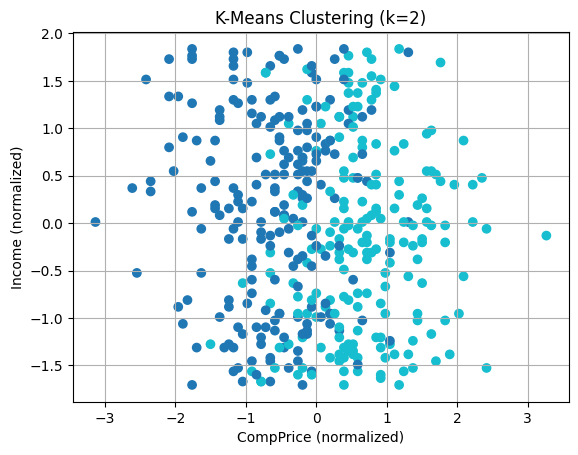

Cluster 0: 206 points
Cluster 1: 194 points


In [4]:
# step2_run_kmeans_and_plot.py

import matplotlib.pyplot as plt

# Ask user for k
k = int(input("Enter number of clusters (K): "))

# Run k-means
labels, centroids = k_means_manual(X, k)

# Visualization: using only first 2 normalized features
plt.scatter(X[:, 0], X[:, 1], c=labels, cmap='tab10')
plt.title(f'K-Means Clustering (k={k})')
plt.xlabel('CompPrice (normalized)')
plt.ylabel('Income (normalized)')
plt.grid(True)
plt.show()

# Print points per cluster
unique, counts = np.unique(labels, return_counts=True)
for i in range(k):
    print(f"Cluster {i}: {counts[i]} points")


**Part (b): K-Medoids Clustering**

In [5]:
# step1_kmedoids_manual.py

import numpy as np
import random

def manhattan_distance(a, b):
    return np.sum(np.abs(a - b))

def assign_medoids(X, medoids):
    labels = []
    for point in X:
        distances = [manhattan_distance(point, m) for m in medoids]
        labels.append(np.argmin(distances))
    return np.array(labels)

def compute_total_cost(X, labels, medoid_idx, k):
    cost = 0
    for i in range(k):
        cluster_points = X[labels == i]
        medoid = X[medoid_idx[i]]
        cost += np.sum([manhattan_distance(p, medoid) for p in cluster_points])
    return cost

def k_medoids_manual(X, k, max_iter=100):
    # Step 1: Initialize medoids randomly
    medoid_idx = random.sample(range(X.shape[0]), k)
    medoids = X[medoid_idx]

    for _ in range(max_iter):
        labels = assign_medoids(X, medoids)
        best_cost = compute_total_cost(X, labels, medoid_idx, k)
        improved = False

        # Try swapping each medoid with each non-medoid
        for i in range(k):
            for j in range(X.shape[0]):
                if j in medoid_idx:
                    continue
                temp_idx = medoid_idx[:]
                temp_idx[i] = j
                temp_medoids = X[temp_idx]
                temp_labels = assign_medoids(X, temp_medoids)
                temp_cost = compute_total_cost(X, temp_labels, temp_idx, k)

                if temp_cost < best_cost:
                    medoid_idx = temp_idx
                    medoids = X[medoid_idx]
                    best_cost = temp_cost
                    improved = True
                    break
            if improved:
                break

        if not improved:
            break

    labels = assign_medoids(X, medoids)
    return labels, medoids


**Run K-Medoids with User-defined K and Plot**

Enter number of clusters (K): 4


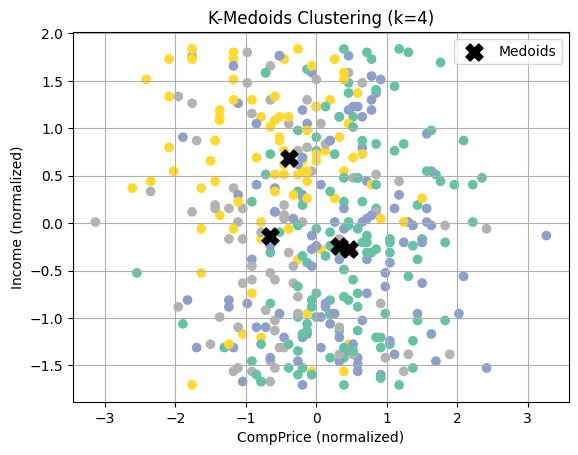

Cluster 0: 129 points
Cluster 1: 104 points
Cluster 2: 89 points
Cluster 3: 78 points


In [6]:
# step2_run_kmedoids_and_plot.py

import matplotlib.pyplot as plt

k = int(input("Enter number of clusters (K): "))

labels_medoids, medoids = k_medoids_manual(X, k)

# Plot result
plt.scatter(X[:, 0], X[:, 1], c=labels_medoids, cmap='Set2')
plt.scatter(medoids[:, 0], medoids[:, 1], color='black', marker='X', s=150, label='Medoids')
plt.title(f"K-Medoids Clustering (k={k})")
plt.xlabel("CompPrice (normalized)")
plt.ylabel("Income (normalized)")
plt.legend()
plt.grid(True)
plt.show()

# Cluster summary
unique, counts = np.unique(labels_medoids, return_counts=True)
for i in range(k):
    print(f"Cluster {i}: {counts[i]} points")


**Part C – Step-by-Step K-Median Manual Implementation a**

In [7]:
import numpy as np

def manhattan_distance(a, b):
    return np.abs(a - b).sum(axis=1)

def k_median_manual(X, k, max_iter=100):
    # Step 1: Randomly initialize medians (select k random points as initial medians)
    np.random.seed(0)
    medians_idx = np.random.choice(len(X), k, replace=False)
    medians = X[medians_idx]

    for _ in range(max_iter):
        # Step 2: Assign each point to the closest median
        labels = []
        for point in X:
            distances = [np.sum(np.abs(point - median)) for median in medians]
            labels.append(np.argmin(distances))
        labels = np.array(labels)

        # Step 3: Update medians (calculate new median of each cluster)
        new_medians = []
        for i in range(k):
            cluster_points = X[labels == i]
            if len(cluster_points) > 0:
                median = np.median(cluster_points, axis=0)
            else:
                # If no points assigned to cluster, reinitialize randomly
                median = X[np.random.choice(len(X))]
            new_medians.append(median)
        new_medians = np.array(new_medians)

        # Step 4: Check for convergence
        if np.allclose(medians, new_medians):
            break
        medians = new_medians

    return labels, medians


**Step 2: Run and Plot Clusters**

Enter the number of clusters (K): 6


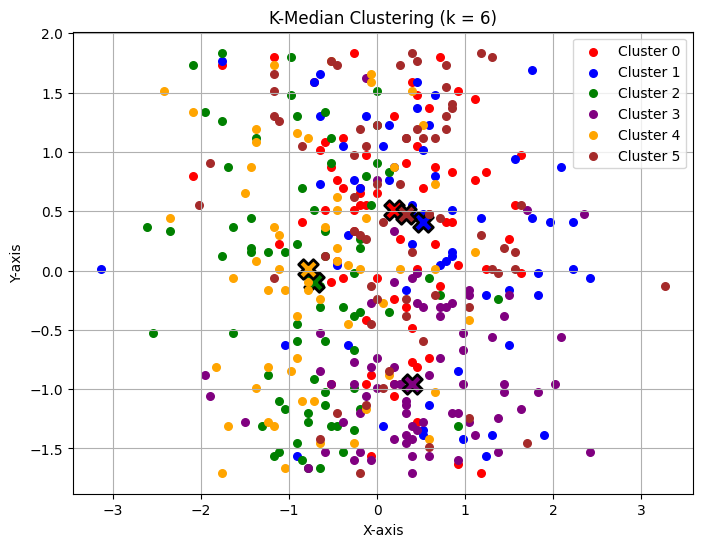

Cluster 0: 68 points
Cluster 1: 58 points
Cluster 2: 72 points
Cluster 3: 74 points
Cluster 4: 61 points
Cluster 5: 67 points


In [9]:
import matplotlib.pyplot as plt

# Take input K from user
k = int(input("Enter the number of clusters (K): "))

# Apply K-Median clustering
labels, medians = k_median_manual(X, k)

# Plot clusters
plt.figure(figsize=(8, 6))
colors = ['red', 'blue', 'green', 'purple', 'orange', 'brown', 'cyan', 'magenta']

for i in range(k):
    cluster_points = X[labels == i]
    plt.scatter(cluster_points[:, 0], cluster_points[:, 1], s=30, color=colors[i % len(colors)], label=f'Cluster {i}')
    plt.scatter(medians[i][0], medians[i][1], s=200, color=colors[i % len(colors)], marker='X', edgecolor='black', linewidth=2)

plt.title(f'K-Median Clustering (k = {k})')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.legend()
plt.grid(True)
plt.show()

# Print how many points in each cluster
for i in range(k):
    count = np.sum(labels == i)
    print(f'Cluster {i}: {count} points')


**Part (d) – Hierarchical Clustering**

Agglomerative Clustering

In [11]:
# step4_agglomerative_manual.py

import numpy as np
import matplotlib.pyplot as plt

def compute_linkage_distance(cluster1, cluster2, linkage):
    if linkage == 'min':
        return np.min([np.linalg.norm(p1 - p2) for p1 in cluster1 for p2 in cluster2])
    elif linkage == 'max':
        return np.max([np.linalg.norm(p1 - p2) for p1 in cluster1 for p2 in cluster2])
    elif linkage == 'avg':
        return np.mean([np.linalg.norm(p1 - p2) for p1 in cluster1 for p2 in cluster2])
    else:
        raise ValueError("Invalid linkage type")

def agglomerative_manual(X, linkage='min'):
    clusters = [[x] for x in X]
    history = []

    while len(clusters) > 1:
        min_dist = float('inf')
        to_merge = (0, 1)

        for i in range(len(clusters)):
            for j in range(i + 1, len(clusters)):
                dist = compute_linkage_distance(clusters[i], clusters[j], linkage)
                if dist < min_dist:
                    min_dist = dist
                    to_merge = (i, j)

        # Save the merge history for dendrogram
        history.append((to_merge[0], to_merge[1], min_dist, len(clusters[to_merge[0]]) + len(clusters[to_merge[1]])))

        # Merge clusters
        merged_cluster = clusters[to_merge[0]] + clusters[to_merge[1]]
        clusters = [c for idx, c in enumerate(clusters) if idx not in to_merge]
        clusters.append(merged_cluster)

    return history


Dendrogram Plotting

In [12]:
# step4_plot_dendrogram.py

def plot_dendrogram(history, title="Agglomerative Dendrogram"):
    import matplotlib.pyplot as plt

    fig, ax = plt.subplots(figsize=(10, 6))

    # Simple plotting logic (not true scipy dendrogram, just lines showing merge steps)
    curr_y = 0
    positions = {}
    n = len(history) + 1

    for i in range(n):
        positions[i] = (i, 0)  # base position for leaf nodes

    for idx, (i, j, dist, size) in enumerate(history):
        x_i, y_i = positions[i]
        x_j, y_j = positions[j]
        x_new = (x_i + x_j) / 2
        y_new = dist
        ax.plot([x_i, x_i], [y_i, y_new], c='black')
        ax.plot([x_j, x_j], [y_j, y_new], c='black')
        ax.plot([x_i, x_j], [y_new, y_new], c='black')
        positions[n + idx] = (x_new, y_new)

    ax.set_title(title)
    ax.set_xlabel("Data Points")
    ax.set_ylabel("Distance")
    plt.grid(True)
    plt.show()


Enter linkage type (min/max/avg): min


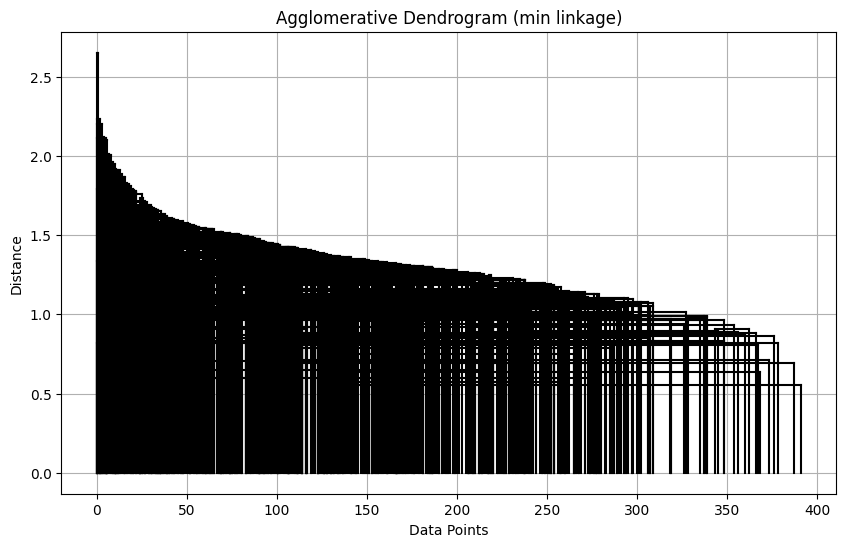

In [13]:
# step4_run_agglomerative.py

linkage = input("Enter linkage type (min/max/avg): ").strip()
history = agglomerative_manual(X, linkage)
plot_dendrogram(history, title=f"Agglomerative Dendrogram ({linkage} linkage)")


**Step 3: Divisive Clustering ** depth = 3

In [14]:
# step4_divisive_manual.py

def divisive_manual(X, depth=3):
    clusters = [X.tolist()]
    history = []

    def recursive_split(cluster, level=0):
        if len(cluster) <= 1 or level >= depth:
            return [cluster]

        # Choose 2 farthest points
        max_dist = 0
        a, b = None, None
        for i in range(len(cluster)):
            for j in range(i+1, len(cluster)):
                dist = np.linalg.norm(np.array(cluster[i]) - np.array(cluster[j]))
                if dist > max_dist:
                    max_dist = dist
                    a, b = cluster[i], cluster[j]

        # Assign to closest of a or b
        group1, group2 = [], []
        for point in cluster:
            if np.linalg.norm(np.array(point) - np.array(a)) < np.linalg.norm(np.array(point) - np.array(b)):
                group1.append(point)
            else:
                group2.append(point)

        history.append((a, b, len(group1), len(group2)))
        return recursive_split(group1, level+1) + recursive_split(group2, level+1)

    final_clusters = recursive_split(X.tolist())
    return final_clusters, history


** Step 4: Plot Venn-style Cluster Diagram (Fake Venn, just separate color scatter)**

In [15]:
# step4_plot_divisive.py

def plot_divisive_clusters(clusters):
    import matplotlib.pyplot as plt
    from matplotlib import cm
    cmap = cm.get_cmap('tab10')

    plt.figure(figsize=(8, 6))
    for idx, cluster in enumerate(clusters):
        cluster = np.array(cluster)
        plt.scatter(cluster[:, 0], cluster[:, 1], color=cmap(idx), label=f"Cluster {idx}")

    plt.title("Divisive Clustering Result")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.grid(True)
    plt.legend()
    plt.show()


/tmp/ipython-input-15-3373601292.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab10')


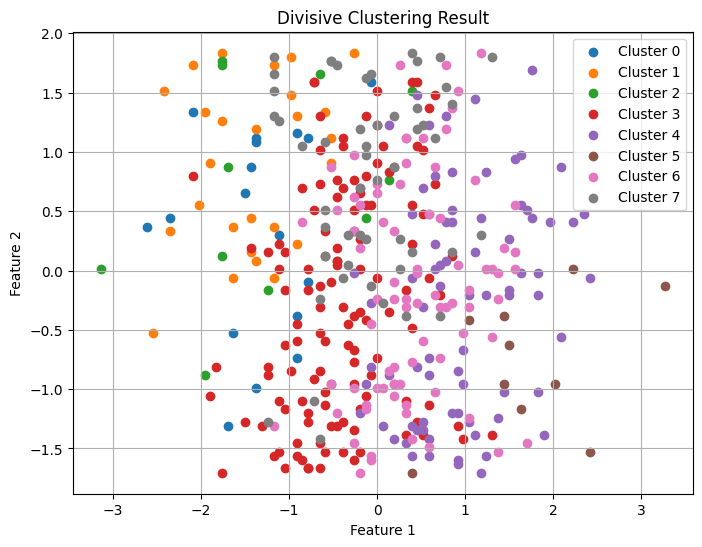

Cluster 0: 18 points
Cluster 1: 26 points
Cluster 2: 12 points
Cluster 3: 124 points
Cluster 4: 78 points
Cluster 5: 10 points
Cluster 6: 82 points
Cluster 7: 50 points


In [16]:
# step4_run_divisive.py

clusters, history = divisive_manual(X, depth=3)
plot_divisive_clusters(clusters)

for i, cluster in enumerate(clusters):
    print(f"Cluster {i}: {len(cluster)} points")


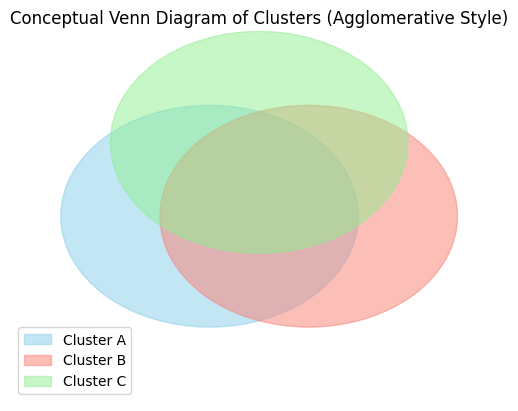

In [18]:
# step6_conceptual_venn_with_matplotlib.py

import matplotlib.pyplot as plt

def draw_conceptual_venn():
    fig, ax = plt.subplots()

    # Draw three overlapping circles (Cluster A, B, C)
    circle1 = plt.Circle((0.4, 0.5), 0.3, color='skyblue', alpha=0.5, label='Cluster A')
    circle2 = plt.Circle((0.6, 0.5), 0.3, color='salmon', alpha=0.5, label='Cluster B')
    circle3 = plt.Circle((0.5, 0.7), 0.3, color='lightgreen', alpha=0.5, label='Cluster C')

    ax.add_patch(circle1)
    ax.add_patch(circle2)
    ax.add_patch(circle3)

    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.axis('off')
    plt.legend()
    plt.title("Conceptual Venn Diagram of Clusters (Agglomerative Style)")
    plt.show()

draw_conceptual_venn()


### **TASK NO 02 : SVM**

In [20]:
import numpy as np
import struct

def load_images(filename):
    with open(filename, 'rb') as f:
        magic, num_images, rows, cols = struct.unpack(">IIII", f.read(16))
        images = np.frombuffer(f.read(), dtype=np.uint8).reshape((num_images, rows * cols))
        return images

def load_labels(filename):
    with open(filename, 'rb') as f:
        magic, num_labels = struct.unpack(">II", f.read(8))
        labels = np.frombuffer(f.read(), dtype=np.uint8)
        return labels

# Replace with your correct paths (on Colab, use '/content/...')
train_images = load_images("/content/train-images.idx3-ubyte")
train_labels = load_labels("/content/train-labels.idx1-ubyte")

test_images = load_images("/content/t10k-images.idx3-ubyte")
test_labels = load_labels("/content/t10k-labels.idx1-ubyte")

print("Train:", train_images.shape, train_labels.shape)
print("Test :", test_images.shape, test_labels.shape)


Train: (60000, 784) (60000,)
Test : (10000, 784) (10000,)


# **Step 2: Train a Linear SVM classifier (One-vs-All)**

In [21]:
import numpy as np
from sklearn.svm import LinearSVC
from sklearn.multiclass import OneVsRestClassifier

# Load data from step 1 (assume already loaded in Colab session)
# train_images, train_labels, test_images, test_labels

# Use only a small subset first (optional, for speed)
X_train = train_images[:10000]  # You can use all: [:60000]
y_train = train_labels[:10000]

# One-vs-All SVM
model = OneVsRestClassifier(LinearSVC(max_iter=5000))
model.fit(X_train, y_train)

train_accuracy = model.score(X_train, y_train)
print("Training Accuracy (Linear SVM without Scaling):", train_accuracy)


Training Accuracy (Linear SVM without Scaling): 0.9828


** Step 3: Standardization + Linear SVM**

In [22]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.multiclass import OneVsRestClassifier

# Reuse your original data (or subset to save time)
X_train = train_images[:10000]
y_train = train_labels[:10000]

# Step 1: Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Step 2: Train Linear SVM again on standardized data
model_scaled = OneVsRestClassifier(LinearSVC(max_iter=5000))
model_scaled.fit(X_train_scaled, y_train)

# Step 3: Accuracy after scaling
train_acc_scaled = model_scaled.score(X_train_scaled, y_train)
print("Training Accuracy (Linear SVM with Standardization):", train_acc_scaled)


/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


KeyboardInterrupt: 

**Part (c): Retrain with Non-Linear SVM (RBF Kernel)**

**Step 4: Train Non-linear SVM (RBF Kernel)**

In [ ]:
from sklearn.svm import SVC

# Use the same scaled data as in part (b)
X_train_subset = X_train_scaled  # already standardized
y_train_subset = y_train

# Train SVM with RBF kernel
rbf_model = SVC(kernel='rbf', gamma='scale')  # gamma='scale' is default
rbf_model.fit(X_train_subset, y_train_subset)

# Training accuracy
train_acc_rbf = rbf_model.score(X_train_subset, y_train_subset)
print("Training Accuracy (SVM with RBF Kernel):", train_acc_rbf)


**Part (d): Make Predictions + Comparative Analysis on Test Set**

Step 5: Prepare test set

In [ ]:
# Use first 2000 test images for quick evaluation
X_test = test_images[:2000]
y_test = test_labels[:2000]

# Standardize using the same scaler as training
X_test_scaled = scaler.transform(X_test)


Step 6: Evaluate all models on test data

In [ ]:
# Predict with linear SVM (from Part b)
y_pred_linear = model_scaled.predict(X_test_scaled)
acc_linear = np.mean(y_pred_linear == y_test)
print("Test Accuracy (Linear SVM):", acc_linear)

# Predict with RBF SVM (from Part c)
y_pred_rbf = rbf_model.predict(X_test_scaled)
acc_rbf = np.mean(y_pred_rbf == y_test)
print("Test Accuracy (RBF Kernel SVM):", acc_rbf)
